In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

repos_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/repos/*.parquet'
artifacts_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifacts/*.parquet'
artifact_siblings_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifact_siblings/*.parquet'
mining_runs_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/mining_runs/*.parquet'
skill_features_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/generated_data/skill_features.parquet'
file_agents_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/generated_data/file_agents.parquet'

con = duckdb.connect(database=':memory:')

## Copies and most-adopted skills

How often the same skill text is copied, and which skills appear in the most files, repositories, and owners.


#### Copies per content

In [3]:
copy_content_frequency = con.execute(f"""
    SELECT cp as number_of_copies, COUNT(*) as number_of_skills
    FROM (SELECT COUNT(*) AS cp
      FROM read_parquet('{artifacts_path}')
      GROUP BY file_sha)
    GROUP BY cp
    ORDER BY cp
""").df()
copy_content_frequency

,number_of_copies,number_of_skills
0,1,1489480
1,2,179980
2,3,74431
3,4,38678
4,5,22763
...,...,...
333,1074,1
334,1176,1
335,1245,1
336,1252,1


This means that there are 1,489,480 skills that have only 1 copy. There are 179,980 skills that have exactly 2 copies, and so on. The maximum number of copies for a single skill is 1,409.

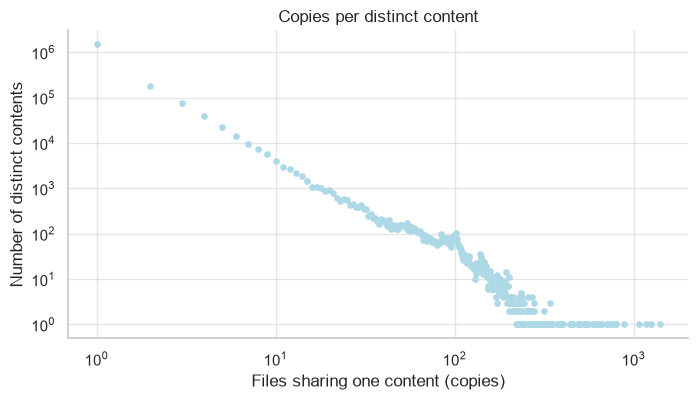

In [4]:
dist = copy_content_frequency
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(dist.number_of_copies, dist.number_of_skills, s=14, c="lightblue")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Files sharing one content (copies)"); ax.set_ylabel("Number of distinct contents")
ax.set_title("Copies per distinct content")
plt.show()
# dist.head(10).to_frame("contents")

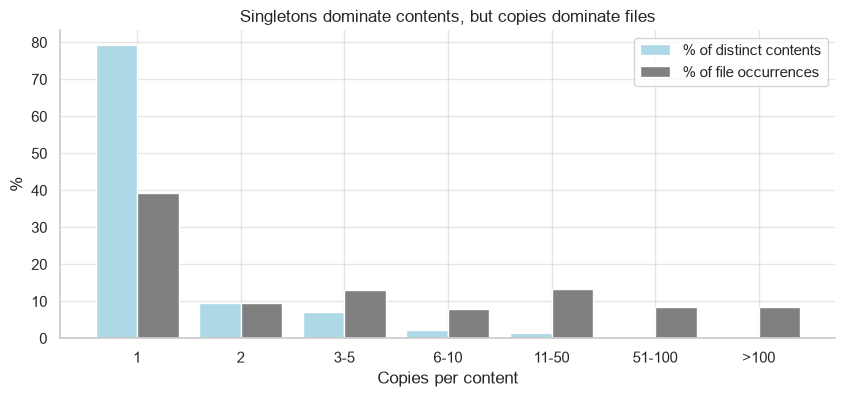

,distinct_skills,total_files,% distinct_skills,% total_files
copy_bucket,,,,
1,1489480,1489480,79.3,39.2
2,179980,359960,9.6,9.5
3-5,135872,491820,7.2,13.0
6-10,40914,303615,2.2,8.0
11-50,25140,510266,1.3,13.4
51-100,4492,322613,0.2,8.5
>100,2103,319363,0.1,8.4


In [5]:
file_frequency = con.execute(f"""
    select
        a.file_sha,
        count(*) as files
    FROM read_parquet('{artifacts_path}') a
    LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
    GROUP BY a.file_sha
""").df()

bins   = [0, 1, 2, 5, 10, 50, 100, np.inf]
labels = ["1", "2", "3-5", "6-10", "11-50", "51-100", ">100"]
file_frequency["copy_bucket"] = pd.cut(file_frequency.files, bins=bins, labels=labels)
bk = file_frequency.groupby("copy_bucket", observed=False).agg(distinct_skills=("file_sha", "size"), total_files=("files", "sum"))
bk["% distinct_skills"] = (100 * bk.distinct_skills / bk.distinct_skills.sum()).round(1)
bk["% total_files"]    = (100 * bk.total_files / bk.total_files.sum()).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(bk)); w = .4
ax.bar(x - w/2, bk["% distinct_skills"], w, label="% of distinct contents", color="lightblue")
ax.bar(x + w/2, bk["% total_files"],    w, label="% of file occurrences", color="gray")
ax.set_xticks(x, bk.index); ax.set_xlabel("Copies per content"); ax.set_ylabel("%")
ax.set_title("Singletons dominate contents, but copies dominate files"); ax.legend()
plt.show()
bk

**Findings (full dataset, 1,877,981 distinct skills / 3,797,117 files)**
- Most skills are unique: 79.3% of distinct skills exist as a single file.
- Most files are shared: 60.8% of files belong to a skill with two or more
  copies; 50.5% of all files are redundant copies (matching the dataset paper).
- Duplication is concentrated: 31,735 skills with more than 10 copies
  (1.6% of distinct skills) account for 30.3% of all files; the 2,103 skills
  with more than 100 copies alone account for 8.4%.
- The sample overstates duplication (74.0% singletons vs 79.3% here) because
  it includes every copy of each selected skill; cite full-dataset figures.

In [6]:
file_frequency = con.execute(f"""
    SELECT MAX(a.name) AS name,
       COUNT(DISTINCT a.repo_full_name) AS repos,
       COUNT(DISTINCT r.owner)          AS owners,
       COUNT(*)                         AS files_per_skill
    FROM read_parquet('{artifacts_path}') a JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
    GROUP BY a.file_sha
    ORDER BY owners DESC
""").df()
file_frequency

,name,repos,owners,files_per_skill
0,frontend-design,951,897,1245
1,verification-before-completion,914,866,1252
2,webapp-testing,781,741,1176
3,systematic-debugging,656,629,885
4,pdf,661,612,1409
...,...,...,...,...
1877976,dual-agent-sync,1,1,1
1877977,wp-wpcli-and-ops,1,1,1
1877978,using-git-worktrees,1,1,1
1877979,"Ebook style guide (voice, terminology, notation)",1,1,1


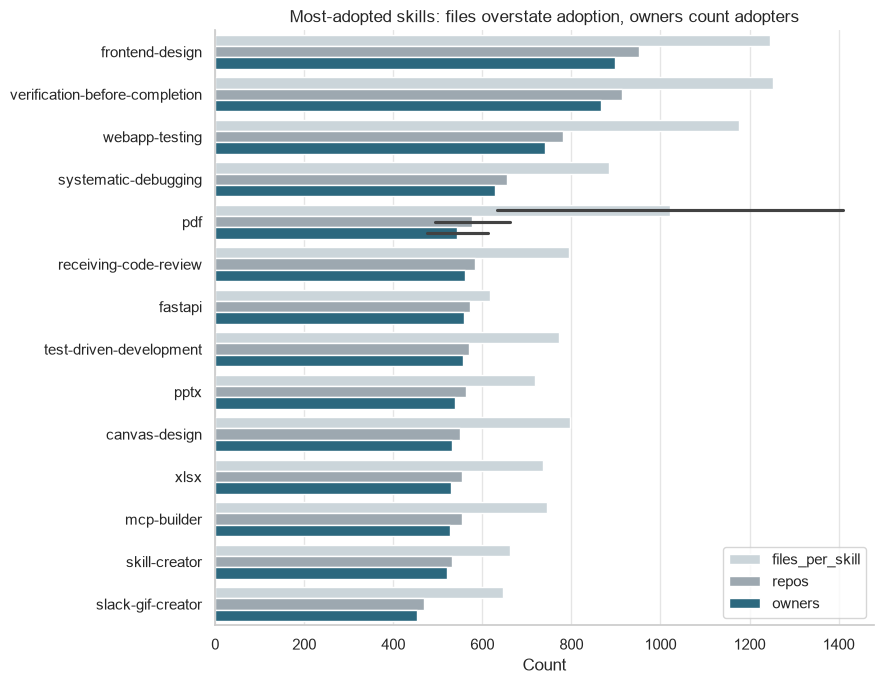

In [7]:
top = file_frequency.head(15).assign(name=lambda d: d.name.fillna("(no name)").str.slice(0, 36))
long = top.melt(id_vars="name", value_vars=["files_per_skill", "repos", "owners"],
                var_name="measure", value_name="count")
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=long, y="name", x="count", hue="measure", orient="h",
            palette=[LIGHT, GREY, ACCENT], order=list(top.name), ax=ax)
ax.set_xlabel("Count"); ax.set_ylabel(""); ax.legend(title="", loc="lower right")
ax.set_title("Most-adopted skills: files overstate adoption, owners count adopters")
plt.tight_layout(); plt.show()

## Most-adopted skills: files per skill, repos and owners

**Findings (full dataset)**
- The most-adopted skills come from a few curated sources: 9 of the top 10 by
  distinct owners match Anthropic's official skills (`frontend-design`, `pdf`,
  `pptx`, `webapp-testing`, `canvas-design`) or the Superpowers collection
  (`verification-before-completion`, `systematic-debugging`,
  `test-driven-development`, `receiving-code-review`).
- `frontend-design` leads with 897 owners across 951 repos (1,245 files).
- Files overstate adoption unevenly: `pdf` has 2.3 files per owner, while
  `fastapi` has 1.1.
- Repos and owners nearly coincide for top skills (owners are 94–97% of repos),
  so in-repo mirroring, not multi-repo copying, drives the file inflation.
- Each row counts one exact text; versions of the same skill split across
  `file_sha` groups, so these figures are a lower bound on adoption.